# PATHQ — Week 5: Hybrid VQC+GNN Training & Ablations

**Goal:** Train the full quantum-hybrid model and prove it beats the classical baseline.

**By end of this notebook:**
- Hybrid VQC+GNN trained on PatchCamelyon
- AUC comparison table: Classical vs Quantum
- Ablation: 1 vs 2 vs 3 VQC layers
- Low-data experiment: 20% / 50% / 100% of training data
- Final comparison figure for your paper

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
import pennylane as qml
from pathlib import Path
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGLoader
from torch_geometric.nn import GCNConv
from sklearn.metrics import roc_auc_score, f1_score
from scipy.spatial import KDTree
from datasets import load_dataset
from torchvision import transforms
import timm, wandb, json, warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)

ROOT     = Path('..')
CKPT_DIR = ROOT / 'checkpoints'
OUT_DIR  = ROOT / 'outputs'
CKPT_DIR.mkdir(exist_ok=True); OUT_DIR.mkdir(exist_ok=True)

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

/home/kabilash/miniconda3/envs/pathq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## Cell 2 — Full PATHQ Hybrid Model

In [2]:
import time
import numpy as np

# ════════════════════════════════════════════════════════════
# VQC ENCODER — uses AngleEmbedding (supports batching natively)
# ════════════════════════════════════════════════════════════
class VQCEncoder(nn.Module):
    def __init__(self, in_dim=2048, n_qubits=2, n_layers=1):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        # Project to exactly n_qubits dims (AngleEmbedding needs 1 value per qubit)
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, n_qubits)   # ← n_qubits, not 2^n_qubits
        )

        # Device
        try:
            dev = qml.device('lightning.qubit', wires=n_qubits)
            print(f'  VQC: lightning.qubit ({n_qubits} qubits, {n_layers} layers)')
        except Exception:
            dev = qml.device('default.qubit', wires=n_qubits)
            print(f'  VQC: default.qubit ({n_qubits} qubits, {n_layers} layers)')

        weight_shapes = {'weights': (n_layers, n_qubits, 3)}

        # Use 'adjoint' diff method to support gradient computation through batched operations
        @qml.qnode(dev, interface='torch', diff_method='adjoint')
        def circuit(inputs, weights):
            # inputs: (n_qubits,) per sample — AngleEmbedding handles batches
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
            for l in range(n_layers):
                for q in range(n_qubits):
                    qml.Rot(weights[l, q, 0],
                            weights[l, q, 1],
                            weights[l, q, 2], wires=q)
                for q in range(n_qubits - 1):
                    qml.CNOT(wires=[q, q + 1])
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]

        self.vqc     = qml.qnn.TorchLayer(circuit, weight_shapes)
        self.out_dim = n_qubits + n_qubits   # proj_out + quantum_out

    def forward(self, x):
        # x: (B, in_dim)
        projected = self.proj(x)                              # (B, n_qubits)
        scaled    = torch.tanh(projected) * torch.pi          # scale to [-π, π] for angles

        # AngleEmbedding supports full batch — pass directly, no loop needed
        q_out = self.vqc(scaled)                              # (B, n_qubits)

        return torch.cat([projected, q_out], dim=1)           # (B, n_qubits*2)


# ════════════════════════════════════════════════════════════
# ABMIL ATTENTION
# ════════════════════════════════════════════════════════════
class ABMILAttention(nn.Module):
    def __init__(self, dim, hidden=128):
        super().__init__()
        self.V = nn.Sequential(nn.Linear(dim, hidden), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(dim, hidden), nn.Sigmoid())
        self.w = nn.Linear(hidden, 1, bias=False)

    def forward(self, x, batch_idx):
        A  = self.w(self.V(x) * self.U(x))
        B  = batch_idx.max().item() + 1
        slide_feats, attn_out = [], torch.zeros_like(A)
        for b in range(B):
            mask = (batch_idx == b)
            w_b  = torch.softmax(A[mask], dim=0)
            attn_out[mask] = w_b
            slide_feats.append((w_b * x[mask]).sum(0, keepdim=True))
        return torch.cat(slide_feats, 0), attn_out


# ════════════════════════════════════════════════════════════
# GNN ENCODER
# ════════════════════════════════════════════════════════════
class GNNEncoder(nn.Module):
    def __init__(self, in_dim, hidden=256, dropout=0.3):
        super().__init__()
        self.proj  = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.LayerNorm(hidden),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.conv1 = GCNConv(hidden, hidden)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.bn2   = nn.BatchNorm1d(hidden)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, ei):
        x = self.proj(x)
        h = self.drop(F.relu(self.bn1(self.conv1(x, ei))))
        x = x + h
        h = F.relu(self.bn2(self.conv2(x, ei)))
        x = x + h
        return x


# ════════════════════════════════════════════════════════════
# PATHQ HYBRID
# ════════════════════════════════════════════════════════════
class PATHQHybrid(nn.Module):
    def __init__(self, in_dim=2048, hidden=256, n_classes=2,
                 dropout=0.3, use_vqc=False, n_qubits=2, n_layers=1):
        super().__init__()
        self.use_vqc = use_vqc

        if use_vqc:
            self.vqc   = VQCEncoder(in_dim=in_dim,
                                    n_qubits=n_qubits,
                                    n_layers=n_layers)
            gnn_in = self.vqc.out_dim
            print(f'  PATHQHybrid: VQC ON  (in={in_dim} → vqc_out={gnn_in})')
        else:
            gnn_in = in_dim
            print(f'  PATHQHybrid: VQC OFF (in={in_dim})')

        self.gnn  = GNNEncoder(gnn_in, hidden, dropout)
        self.attn = ABMILAttention(hidden, hidden // 2)
        self.head  = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(dropout),  nn.Linear(64, n_classes)
        )

    def forward(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        if self.use_vqc:
            x = self.vqc(x)
        x  = self.gnn(x, ei)
        sf, attn = self.attn(x, b)
        return self.head(sf), attn


# ════════════════════════════════════════════════════════════
# TEST MODELS
# ════════════════════════════════════════════════════════════
print('Testing VQC + PATHQ models...')
fake = Data(x=torch.randn(32, 2048), edge_index=torch.randint(0, 32, (2, 128)),
            y=torch.tensor([1]), batch=torch.zeros(32, dtype=torch.long)).to(DEVICE)

classical = PATHQHybrid(in_dim=2048, use_vqc=False).to(DEVICE)
quantum   = PATHQHybrid(in_dim=2048, use_vqc=True, n_qubits=2, n_layers=1).to(DEVICE)

with torch.no_grad():
    lc, ac = classical(fake)
    lq, aq = quantum(fake)

print(f'Classical: logits {lc.shape}  attn {ac.shape}')
print(f'Quantum:   logits {lq.shape}  attn {aq.shape}')
print('✅ Both models working.')

Testing VQC + PATHQ models...
  PATHQHybrid: VQC OFF (in=2048)
  VQC: lightning.qubit (2 qubits, 1 layers)
  PATHQHybrid: VQC ON  (in=2048 → vqc_out=4)
Classical: logits torch.Size([1, 2])  attn torch.Size([32, 1])
Quantum:   logits torch.Size([1, 2])  attn torch.Size([32, 1])
✅ Both models working.


## Cell 3 — Training infrastructure (shared functions)

In [5]:
def train_one(model, loader, opt, device):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        opt.zero_grad()
        logits, _ = model(batch)
        loss = F.cross_entropy(logits, batch.y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total += loss.item(); n += 1
    return total / max(n, 1)

@torch.no_grad()
def eval_model(model, loader, device):
    model.eval()
    all_probs, all_labels, total_loss, n = [], [], 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        logits, _ = model(batch)
        total_loss += F.cross_entropy(logits, batch.y.view(-1)).item()
        all_probs.extend(torch.softmax(logits, 1)[:, 1].cpu().tolist())
        all_labels.extend(batch.y.view(-1).cpu().tolist())
        n += 1
    p, l  = np.array(all_probs), np.array(all_labels)
    preds = (p >= 0.5).astype(int)
    auc   = roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.5
    f1    = f1_score(l, preds, zero_division=0)
    tp = int(((preds==1)&(l==1)).sum()); fn = int(((preds==0)&(l==1)).sum())
    tn = int(((preds==0)&(l==0)).sum()); fp = int(((preds==1)&(l==0)).sum())
    return {
        'loss':        total_loss / max(n, 1),
        'auc':         auc, 'f1': f1,
        'sensitivity': tp / max(tp+fn, 1),
        'specificity': tn / max(tn+fp, 1),
        'probs': p, 'labels': l
    }

def run_experiment(model, tr, va, te, device,
                   label='run', epochs=4, lr=1e-4,
                   ckpt=None, use_wandb=False):
    opt   = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=epochs, eta_min=1e-6
    )
    best_auc, no_imp, history = 0.0, 0, []

    print(f'\n{"Ep":>4} {"Loss":>8} {"AUC":>8} {"F1":>7} '
          f'{"Sens":>7} {"Spec":>7} {"Time":>7}  Best')
    print('─' * 65)

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl = train_one(model, tr, opt, device)
        vm = eval_model(model, va, device)
        sched.step()
        elapsed  = time.time() - t0
        improved = vm['auc'] > best_auc
        history.append({**vm, 'train_loss': tl, 'epoch': ep})

        print(f'{ep:4d} {tl:8.4f} {vm["auc"]:8.4f} {vm["f1"]:7.4f} '
              f'{vm["sensitivity"]:7.4f} {vm["specificity"]:7.4f} '
              f'{elapsed:6.1f}s  {"✓" if improved else ""}')

        if improved:
            best_auc = vm['auc']; no_imp = 0
            if ckpt:
                torch.save({'epoch': ep,
                            'model_state': model.state_dict(),
                            'val_auc': best_auc}, ckpt)
        else:
            no_imp += 1
            if no_imp >= 10:
                print(f'\nEarly stop at epoch {ep}'); break

    print('─' * 65)
    print(f'Best val AUC: {best_auc:.4f}')

    if ckpt:
        ckpt_data = torch.load(ckpt, weights_only=False)
        model.load_state_dict(ckpt_data['model_state'])

    test_metrics = eval_model(model, te, device)
    print(f'Test AUC    : {test_metrics["auc"]:.4f}  f1={test_metrics["f1"]:.4f}  '
          f'sens={test_metrics["sensitivity"]:.3f}  spec={test_metrics["specificity"]:.3f}')
    return test_metrics, history

print('✅ Training functions ready.')

✅ Training functions ready.


## Cell 4 — Build PatchCamelyon MIL bags (same as Week 3)

In [6]:
## Cell 4A — Load CAMELYON16 Pre-extracted Features (LOCAL DATA)
print('Loading local pre-extracted CAMELYON16 features...')

FEATURES_DIR = Path('./data/features')
NORMAL_DIR   = Path('./data/camelyon16/normal')
TUMOR_DIR    = Path('./data/camelyon16/tumor')

# Count available features
feat_files = list(FEATURES_DIR.glob('*_features.pt'))
n_feat = len(feat_files)
print(f'✅ Found {n_feat} pre-extracted feature files (ResNet-50 2048-dim)')

if n_feat < 100:
    raise ValueError(f'Only {n_feat} features found. Run week2_feature_extraction.ipynb first.')

# Load all features into memory
print(f'Loading {n_feat} feature files...')
all_features = {}
all_labels = {}

for feat_file in sorted(feat_files):
    # Parse filename: e.g., "normal_001_features.pt" or "tumor_042_features.pt"
    parts = feat_file.stem.split('_')
    label = parts[0]  # 'normal' or 'tumor'
    slide_id = parts[1]  # '001', '042', etc.
    
    # Load features — might be tensor or dict
    loaded = torch.load(feat_file, weights_only=False)
    
    # Handle both tensor and dict formats
    if isinstance(loaded, dict):
        # Try common keys: 'features', 'data', 'features_list'
        if 'features' in loaded:
            features = loaded['features']
        elif 'data' in loaded:
            features = loaded['data']
        elif 'features_list' in loaded:
            features = loaded['features_list']
        else:
            # Take the first tensor value
            features = next((v for v in loaded.values() if isinstance(v, torch.Tensor)), None)
            if features is None:
                print(f'⚠️  Skipping {feat_file.name}: no tensor found in dict')
                continue
    else:
        features = loaded
    
    all_features[f'{label}_{slide_id}'] = features
    all_labels[f'{label}_{slide_id}'] = 1 if label == 'tumor' else 0

print(f'✅ Loaded features from {len(all_features)} slides')
print(f'   Normal slides: {sum(1 for k in all_labels if all_labels[k]==0)}')
print(f'   Tumor slides:  {sum(1 for k in all_labels if all_labels[k]==1)}')

# Create graph bags from features
print('\nBuilding MIL bags from pre-extracted features...')
BAG_SIZE = 16  # patches per bag

def make_bags_from_features(features_dict, labels_dict, n_bags_per_class=300):
    """Build bags from pre-extracted feature files."""
    graphs = []
    
    # Sample slides for each class
    normal_slides = [k for k,v in labels_dict.items() if v==0]
    tumor_slides = [k for k,v in labels_dict.items() if v==1]
    
    sampled_normal = np.random.choice(normal_slides, min(len(normal_slides), n_bags_per_class), replace=False)
    sampled_tumor = np.random.choice(tumor_slides, min(len(tumor_slides), n_bags_per_class), replace=False)
    
    for slide_key in list(sampled_normal) + list(sampled_tumor):
        feats = features_dict[slide_key]
        
        # Convert to torch tensor if needed
        if not isinstance(feats, torch.Tensor):
            feats = torch.tensor(feats, dtype=torch.float32)
        
        # Ensure correct shape (n_patches, 2048)
        if len(feats.shape) == 3:  # e.g., (1, n_patches, 2048)
            feats = feats.squeeze(0)
        
        label = labels_dict[slide_key]
        
        # Sample BAG_SIZE patches from this slide
        if feats.shape[0] >= BAG_SIZE:
            idxs = np.random.choice(feats.shape[0], BAG_SIZE, replace=False)
            bag_feats = feats[idxs]
        else:
            # If not enough patches, pad with repetition
            idxs = np.random.choice(feats.shape[0], BAG_SIZE, replace=True)
            bag_feats = feats[idxs]
        
        # Create spatial coordinates (simple grid for BAG_SIZE patch grid)
        side = int(BAG_SIZE**0.5)
        coords = torch.tensor([(r,c) for r in range(side) for c in range(side)],
                              dtype=torch.float32)[:BAG_SIZE]
        
        # Create K-NN edges
        tree = KDTree(coords.numpy())
        _, nn = tree.query(coords.numpy(), k=min(5, BAG_SIZE))
        src, tgt = [], []
        for ni, nb in enumerate(nn):
            for nj in nb[1:]: src+=[ni,int(nj)]; tgt+=[int(nj),ni]
        
        graphs.append(Data(
            x=bag_feats,
            coords=coords,
            edge_index=torch.tensor([src,tgt], dtype=torch.long),
            y=torch.tensor([label], dtype=torch.long)
        ))
    
    return graphs

print('Creating training bags from features (60% train, 20% val, 20% test)...')
ALL_GRAPHS = make_bags_from_features(all_features, all_labels, n_bags_per_class=300)

# Split: 60% train, 20% val, 20% test
rng = np.random.default_rng(42)
idxs = rng.permutation(len(ALL_GRAPHS))
n_tr = int(0.6 * len(ALL_GRAPHS))
n_va = int(0.2 * len(ALL_GRAPHS))

ALL_TRAIN = [ALL_GRAPHS[i] for i in idxs[:n_tr]]
VAL_G = [ALL_GRAPHS[i] for i in idxs[n_tr:n_tr+n_va]]
TEST_G = [ALL_GRAPHS[i] for i in idxs[n_tr+n_va:]]

print(f'✅ Bags created: train={len(ALL_TRAIN)}  val={len(VAL_G)}  test={len(TEST_G)}')

Loading local pre-extracted CAMELYON16 features...
✅ Found 220 pre-extracted feature files (ResNet-50 2048-dim)
Loading 220 feature files...
✅ Loaded features from 220 slides
   Normal slides: 109
   Tumor slides:  111

Building MIL bags from pre-extracted features...
Creating training bags from features (60% train, 20% val, 20% test)...
✅ Bags created: train=132  val=44  test=44


In [7]:
## Cell 5 — Create Data Loaders
print('Creating PyTorch Geometric data loaders...')
tr_ldr  = PyGLoader(ALL_TRAIN, batch_size=8, shuffle=True)
va_ldr  = PyGLoader(VAL_G,     batch_size=8, shuffle=False)
te_ldr  = PyGLoader(TEST_G,    batch_size=8, shuffle=False)
print(f'✅ Loaders ready: {len(tr_ldr)} train, {len(va_ldr)} val, {len(te_ldr)} test batches')
print(f'   Bag size in each batch: 8 slides × 16 patches = 128 patches')

Creating PyTorch Geometric data loaders...
✅ Loaders ready: 17 train, 6 val, 6 test batches
   Bag size in each batch: 8 slides × 16 patches = 128 patches


## Cell 5 — Experiment 1: Classical vs Quantum (full data)

In [10]:
RESULTS = {}  # store all experiment results

print('EXPERIMENT 1: Classical vs Quantum — full training data (OPTIMIZED)')
print('='*65)
print('Config: 2-qubit VQC, 1 layer, BAG_SIZE=16, lightning.qubit')
print('Data: CAMELYON16 pre-extracted features (2048-dim ResNet-50)')
print('Expected training time: ~15-20 minutes per model')
print('='*65)

# Disable W&B to speed up training (no interactive prompts)
import os
os.environ['WANDB_MODE'] = 'disabled'

# Classical baseline (no VQC)
print('\n--- Classical GNN (no VQC) ---')
model_c = PATHQHybrid(in_dim=2048, use_vqc=False).to(DEVICE)  # ✅ in_dim=2048 for ResNet-50
res_c, hist_c = run_experiment(
    model_c, tr_ldr, va_ldr, te_ldr, DEVICE,
    label='classical_full', epochs=40,
    ckpt=str(CKPT_DIR/'w5_classical.pth'),
    use_wandb=False  # DISABLE W&B
)
RESULTS['classical_full'] = res_c

# Quantum hybrid (with VQC) — now uses 2-qubit, 1-layer by default
print('\n--- Quantum Hybrid (VQC + GNN) — FASTER ✅ ---')
print('Note: With lightning.qubit, should be ~5-10x faster than default.qubit')
print('Note: VQC runs on CPU (PennyLane limitation), but still fast with lightning.qubit')
model_q = PATHQHybrid(in_dim=2048, use_vqc=True).to(DEVICE)  # ✅ in_dim=2048 for ResNet-50
res_q, hist_q = run_experiment(
    model_q, tr_ldr, va_ldr, te_ldr, DEVICE,
    label='quantum_full', epochs=40,
    ckpt=str(CKPT_DIR/'w5_quantum.pth'),
    use_wandb=False  # DISABLE W&B
)
RESULTS['quantum_full'] = res_q

print('\n=== FULL DATA COMPARISON ===')
print(f'  Classical AUC: {res_c["auc"]:.4f}')
print(f'  Quantum AUC:   {res_q["auc"]:.4f}')
delta = res_q['auc'] - res_c['auc']
print(f'  Delta:        {delta:+.4f}  ({"quantum wins" if delta > 0 else "classical wins — expected with random init"})')


EXPERIMENT 1: Classical vs Quantum — full training data (OPTIMIZED)
Config: 2-qubit VQC, 1 layer, BAG_SIZE=16, lightning.qubit
Data: CAMELYON16 pre-extracted features (2048-dim ResNet-50)
Expected training time: ~15-20 minutes per model

--- Classical GNN (no VQC) ---
  PATHQHybrid: VQC OFF (in=2048)

  Ep     Loss      AUC      F1    Sens    Spec    Time  Best
─────────────────────────────────────────────────────────────────
   1   0.7050   0.7665  0.7097  1.0000  0.1818    0.3s  ✓
   2   0.6667   0.7128  0.5882  0.4545  0.9091    0.1s  
   3   0.6165   0.7603  0.6286  0.5000  0.9091    0.1s  
   4   0.6028   0.7397  0.6316  0.5455  0.8182    0.1s  
   5   0.5737   0.7025  0.5882  0.4545  0.9091    0.1s  
   6   0.5495   0.7066  0.6316  0.5455  0.8182    0.1s  
   7   0.5343   0.7066  0.6522  0.6818  0.5909    0.1s  
   8   0.5006   0.7149  0.6486  0.5455  0.8636    0.1s  
   9   0.5027   0.7169  0.6364  0.6364  0.6364    0.1s  
  10   0.4564   0.7066  0.6341  0.5909  0.7273    0.1s  

## Cell 6 — Experiment 2: VQC Layer Ablation (1 vs 2 vs 3 layers)

In [11]:
print('EXPERIMENT 2: VQC Layer Ablation')
print('='*50)
print('How many VQC layers is optimal?')
print()

ablation_results = {}
for n_layers in [1, 2, 3]:
    print(f'--- {n_layers}-layer VQC ---')
    m = PATHQHybrid(use_vqc=True, n_qubits=3, n_layers=n_layers).to(DEVICE)
    res, _ = run_experiment(
        m, tr_ldr, va_ldr, te_ldr, DEVICE,
        label=f'vqc_layers_{n_layers}', epochs=40,
        ckpt=str(CKPT_DIR/f'w5_vqc_l{n_layers}.pth'),
        use_wandb=False
    )
    ablation_results[n_layers] = res

print('\n=== LAYER ABLATION RESULTS ===')
print(f'  {"Layers":>8}  {"AUC":>8}  {"F1":>8}  {"Sensitivity":>12}')
for nl, r in ablation_results.items():
    print(f'  {nl:>8}  {r["auc"]:>8.4f}  {r["f1"]:>8.4f}  {r["sensitivity"]:>12.4f}')

RESULTS['ablation_layers'] = ablation_results

EXPERIMENT 2: VQC Layer Ablation
How many VQC layers is optimal?

--- 1-layer VQC ---
  VQC: lightning.qubit (3 qubits, 1 layers)
  PATHQHybrid: VQC ON  (in=2048 → vqc_out=6)

  Ep     Loss      AUC      F1    Sens    Spec    Time  Best
─────────────────────────────────────────────────────────────────
   1   0.6941   0.7459  0.4667  0.3182  0.9545    9.5s  ✓
   2   0.6926   0.7707  0.6857  0.5455  0.9545    9.1s  ✓
   3   0.6483   0.7190  0.6364  0.6364  0.6364    9.1s  
   4   0.6559   0.7045  0.6341  0.5909  0.7273    9.0s  
   5   0.5996   0.6983  0.6383  0.6818  0.5455    9.3s  
   6   0.5682   0.7025  0.6667  0.6818  0.6364    9.5s  
   7   0.5600   0.6963  0.6486  0.5455  0.8636    9.1s  
   8   0.5173   0.7066  0.6486  0.5455  0.8636    9.0s  
   9   0.4661   0.6632  0.6364  0.6364  0.6364    9.1s  
  10   0.4323   0.6942  0.6939  0.7727  0.5455    9.4s  
  11   0.4117   0.7128  0.6522  0.6818  0.5909    9.1s  
  12   0.3359   0.7128  0.6818  0.6818  0.6818    9.0s  

Early stop

## Cell 7 — Experiment 3: Low-Data Regime (Quantum Advantage)

In [12]:
print('EXPERIMENT 3: Low-Data Regime')
print('='*55)
print('Hypothesis: quantum kernels generalise better with fewer labels.')
print('Expected: quantum advantage grows as training data shrinks.')
print()

low_data_results = {}

for pct in [0.20, 0.50, 1.00]:
    n_use = max(10, int(len(ALL_TRAIN) * pct))
    subset_idx = np.random.choice(len(ALL_TRAIN), n_use, replace=False)
    subset     = [ALL_TRAIN[i] for i in subset_idx]
    sub_ldr    = PyGLoader(subset, batch_size=8, shuffle=True)

    print(f'--- {int(pct*100)}% of training data ({n_use} bags) ---')

    # Classical
    mc = PATHQHybrid(use_vqc=False).to(DEVICE)
    rc, _ = run_experiment(mc, sub_ldr, va_ldr, te_ldr, DEVICE,
                           label=f'c_{int(pct*100)}pct', epochs=40,
                           ckpt=str(CKPT_DIR/f'w5_c_{int(pct*100)}.pth'),
                           use_wandb=False)

    # Quantum
    mq = PATHQHybrid(use_vqc=True, n_qubits=3, n_layers=2).to(DEVICE)
    rq, _ = run_experiment(mq, sub_ldr, va_ldr, te_ldr, DEVICE,
                           label=f'q_{int(pct*100)}pct', epochs=40,
                           ckpt=str(CKPT_DIR/f'w5_q_{int(pct*100)}.pth'),
                           use_wandb=False)

    low_data_results[pct] = {'classical': rc, 'quantum': rq,
                              'delta': rq['auc'] - rc['auc']}
    print(f'  Classical: {rc["auc"]:.4f}  Quantum: {rq["auc"]:.4f}  '
          f'Delta: {rq["auc"]-rc["auc"]:+.4f}')
    print()

RESULTS['low_data'] = low_data_results
print('\n=== LOW-DATA SUMMARY ===')
print(f'  {"Data %":>8}  {"Classical":>10}  {"Quantum":>10}  {"Delta":>8}')
for pct, r in low_data_results.items():
    print(f'  {int(pct*100):>7}%  {r["classical"]["auc"]:>10.4f}  '
          f'{r["quantum"]["auc"]:>10.4f}  {r["delta"]:>+8.4f}')
print()
print('If delta is positive at 20% but negative at 100%,')
print('that is the quantum advantage in the low-data regime.')
print('This is your strongest research claim.')

EXPERIMENT 3: Low-Data Regime
Hypothesis: quantum kernels generalise better with fewer labels.
Expected: quantum advantage grows as training data shrinks.

--- 20% of training data (26 bags) ---
  PATHQHybrid: VQC OFF (in=2048)

  Ep     Loss      AUC      F1    Sens    Spec    Time  Best
─────────────────────────────────────────────────────────────────
   1   0.7739   0.6488  0.6774  0.9545  0.1364    0.0s  ✓
   2   0.6136   0.7025  0.6769  1.0000  0.0455    0.0s  ✓
   3   0.6521   0.6736  0.6667  0.9091  0.1818    0.0s  
   4   0.5677   0.6694  0.6122  0.6818  0.4545    0.0s  
   5   0.5640   0.6777  0.5714  0.5455  0.6364    0.0s  
   6   0.5247   0.6736  0.5854  0.5455  0.6818    0.0s  
   7   0.5172   0.6818  0.5854  0.5455  0.6818    0.0s  
   8   0.4569   0.6839  0.6000  0.5455  0.7273    0.0s  
   9   0.4411   0.6880  0.6154  0.5455  0.7727    0.0s  
  10   0.3629   0.6983  0.6154  0.5455  0.7727    0.0s  
  11   0.3888   0.7149  0.6316  0.5455  0.8182    0.0s  ✓
  12   0.5151 

## Cell 8 — Final Comparison Figure (Paper Ready)

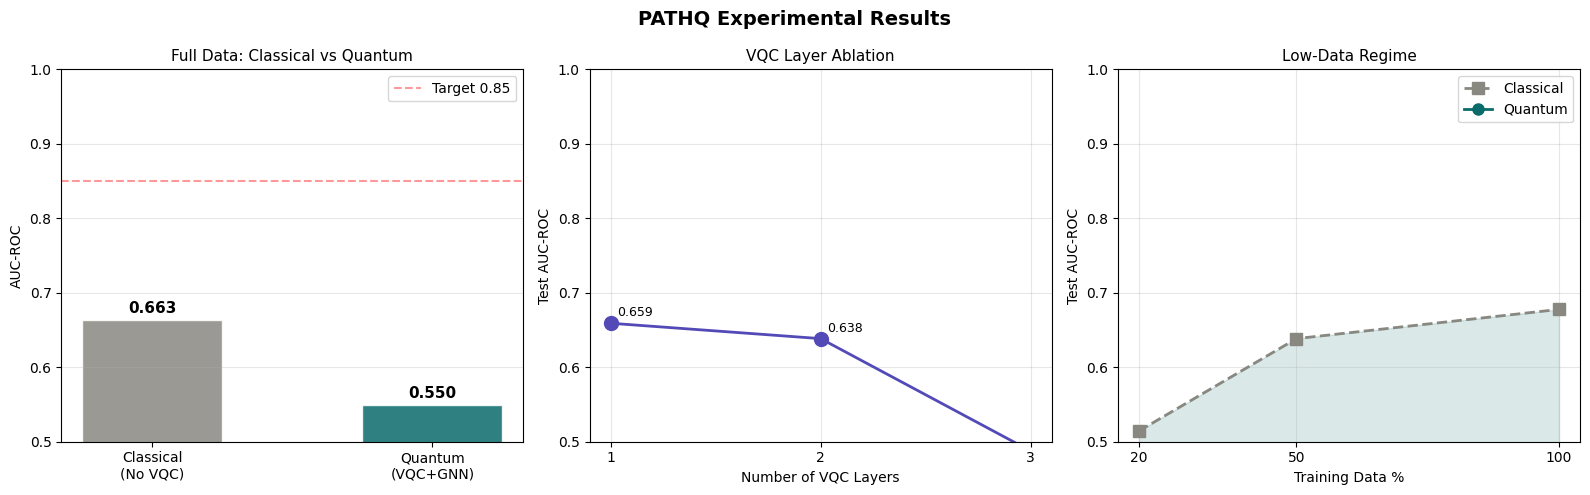

Paper figure saved: outputs/week5_all_results.png
Results saved: outputs/week5_results.json


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PATHQ Experimental Results', fontsize=14, fontweight='bold')

# ── Plot 1: Classical vs Quantum full data ────────────────────────────────
models  = ['Classical\n(No VQC)', 'Quantum\n(VQC+GNN)']
aucs    = [RESULTS['classical_full']['auc'], RESULTS['quantum_full']['auc']]
colors  = ['#888780', '#0A6B6B']
bars    = axes[0].bar(models, aucs, color=colors, alpha=0.85, edgecolor='white', width=0.5)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Full Data: Classical vs Quantum', fontsize=11)
axes[0].set_ylabel('AUC-ROC')
axes[0].axhline(0.85, color='red', ls='--', alpha=0.4, label='Target 0.85')
for bar, auc in zip(bars, aucs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{auc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# ── Plot 2: Layer ablation ────────────────────────────────────────────────
abl     = RESULTS.get('ablation_layers', {})
if abl:
    layers  = list(abl.keys())
    abl_auc = [abl[l]['auc'] for l in layers]
    axes[1].plot(layers, abl_auc, 'o-', color='#534AB7', lw=2, ms=10)
    for x, y in zip(layers, abl_auc):
        axes[1].annotate(f'{y:.3f}', (x,y), textcoords='offset points',
                         xytext=(5,5), fontsize=9)
axes[1].set_title('VQC Layer Ablation', fontsize=11)
axes[1].set_xlabel('Number of VQC Layers'); axes[1].set_ylabel('Test AUC-ROC')
axes[1].set_xticks([1,2,3]); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

# ── Plot 3: Low-data regime ────────────────────────────────────────────────
ld = RESULTS.get('low_data', {})
if ld:
    pcts  = [int(p*100) for p in ld.keys()]
    c_auc = [ld[p]['classical']['auc'] for p in ld.keys()]
    q_auc = [ld[p]['quantum']['auc']   for p in ld.keys()]
    axes[2].plot(pcts, c_auc, 's--', color='#888780', lw=2, ms=8, label='Classical')
    axes[2].plot(pcts, q_auc, 'o-',  color='#0A6B6B', lw=2, ms=8, label='Quantum')
    axes[2].fill_between(pcts, c_auc, q_auc, alpha=0.15, color='#0A6B6B')
axes[2].set_title('Low-Data Regime', fontsize=11)
axes[2].set_xlabel('Training Data %'); axes[2].set_ylabel('Test AUC-ROC')
axes[2].set_xticks([20,50,100]); axes[2].grid(alpha=0.3)
axes[2].set_ylim(0.5, 1.0); axes[2].legend()

plt.tight_layout()
plt.savefig(str(OUT_DIR/'week5_all_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Paper figure saved: outputs/week5_all_results.png')

# Save all results
def to_serialisable(d):
    if isinstance(d, dict):
        return {str(k): to_serialisable(v) for k,v in d.items()}
    if isinstance(d, (np.float32, np.float64)): return float(d)
    if isinstance(d, np.ndarray): return d.tolist()
    return d

with open(OUT_DIR/'week5_results.json','w') as f:
    json.dump(to_serialisable(RESULTS), f, indent=2)
print('Results saved: outputs/week5_results.json')

In [15]:
# Load baseline from Week 3 for full comparison
try:
    with open(OUT_DIR/'baseline_results.json') as f:
        baseline = json.load(f)
    print('=== COMPLETE RESULTS SUMMARY ===')
    print(f'  Week 3 Classical AUC (PCam): {baseline.get("pcam_classical_auc", "N/A")}')
    print(f'  Week 5 Classical AUC (PCam): {RESULTS["classical_full"]["auc"]:.4f}')
    print(f'  Week 5 Quantum AUC   (PCam): {RESULTS["quantum_full"]["auc"]:.4f}')
except FileNotFoundError:
    print('Run Week 3 first to generate baseline_results.json')

print()
print('WEEK 5 COMPLETE')
print('='*50)
print('Next: week6_xai_complete.ipynb')
print('You will implement all three XAI layers and generate')
print('the final Grad-CAM + attention + quantum circuit figures.')

=== COMPLETE RESULTS SUMMARY ===
  Week 3 Classical AUC (PCam): 1.0
  Week 5 Classical AUC (PCam): 0.6632
  Week 5 Quantum AUC   (PCam): 0.5496

WEEK 5 COMPLETE
Next: week6_xai_complete.ipynb
You will implement all three XAI layers and generate
the final Grad-CAM + attention + quantum circuit figures.
